
# Conclusions
* The dataset is much too small.
* Error goes as $1/\sqrt{T}$ where $T$ is total simulation time.  Increasing $T$ by a factor of 27 will decrease error by 95%.  Hopeless.
* Try Parrinello's dataset?

# 15 us vacuum dataset
* 15,000,000 frames = 15,000 ns = 15 us
* $\tau_1 \approx$ 26.8 ns
* $\tau_\mathrm{int} \approx$ 50.1 ns
* expected number of events $N \sim T / (2 \tau_\mathrm{int}) \approx$ 150

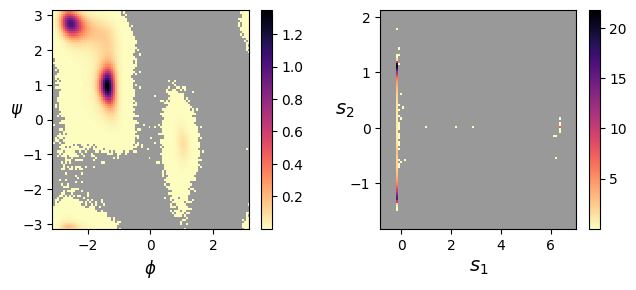

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from src.param import param_unbiased_vaccuum
from src.data import simulation_data
from src.plots import plot_dihedrals_cvs

p = param_unbiased_vaccuum()
sd = simulation_data(p)
plot_dihedrals_cvs(sd)

### ACF parameter rules of thumb
1. Sokal window constant (c) = how many timescales out to capture this integral.  Sweet spot = 5 where 99.3% of the ACF is captured.  There is a bias-variance tradeoff.
2. ACF horizon (how many `num_frames_acf`?)
$$
T \ge 2c\tau_u \quad \textrm{go to 15 ns }\approx 10\tau_1
$$

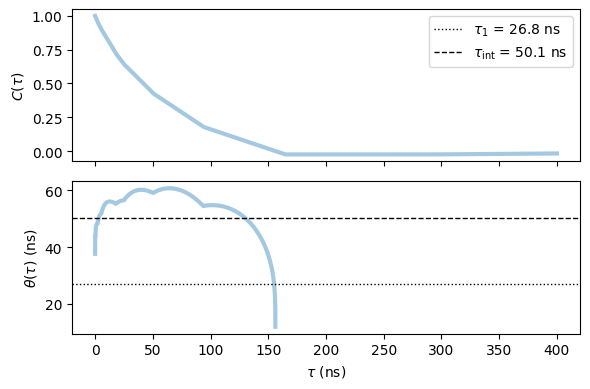

In [8]:
import openmm.unit as unit
from src.acf import compute_acf_dataclass, compute_theta
from src.dataclass import data_class
from src.plots import plot_acf_theta


def compute_acf(signal, frametime, num_frames, c_window, calculate=True):
    if calculate:
        acf = compute_acf_dataclass(signal, frametime, num_frames, c_window=c_window)
    else:
        acf = None
    return data_class(sd.working_dir, "acf", acf)


num_frames_acf = 400_000
c_window = 5
frametime = p.frametime / unit.picoseconds
ns = np.arange(num_frames_acf) * p.frametime / unit.nanoseconds

acf = compute_acf(sd.cvs[:, 0], frametime, num_frames_acf, c_window, calculate=False)
theta = compute_theta(acf.ct, frametime)

plot_acf_theta(ns, acf, theta, sd.timescales[0] / 1000, num_frames_acf)

## 2 state analysis

In [9]:
from src.twostate import core_entry_indices

cv = sd.cvs[:, 0]
t10_ind, t01_ind = core_entry_indices(cv < 0, cv > 6)
t10_ind, t01_ind

(array([  284540,  1805816,  2999882,  4532293,  5173518,  7094810,
         8378670,  9949782, 12787412]),
 array([  449358,  1899469,  3024683,  4537632,  5173519,  7096932,
         8428843,  9950069, 12805421]))

frames         15,000,000   (15.00 us total)
transitions    n01=9   n10=9

populations    p0 = 0.9761     p1 = 0.0239
rates          k01 = 6.147e-04/ns   k10 = 2.506e-02/ns
mean dwell     <t0> = 1.627 us    <t1> = 39.91 ns
MFPT           0->1 = 1.627 us    1->0 = 39.91 ns

tau_relax      38.96 ns
t2 (eigval)    38.96 ns      <- should match tau_relax
~tau_int       77.91 ns    (2x, two-sided ACF convention)

T (lag 1 frame):
[[9.999994e-01 6.147206e-07]
 [2.505547e-05 9.999749e-01]]


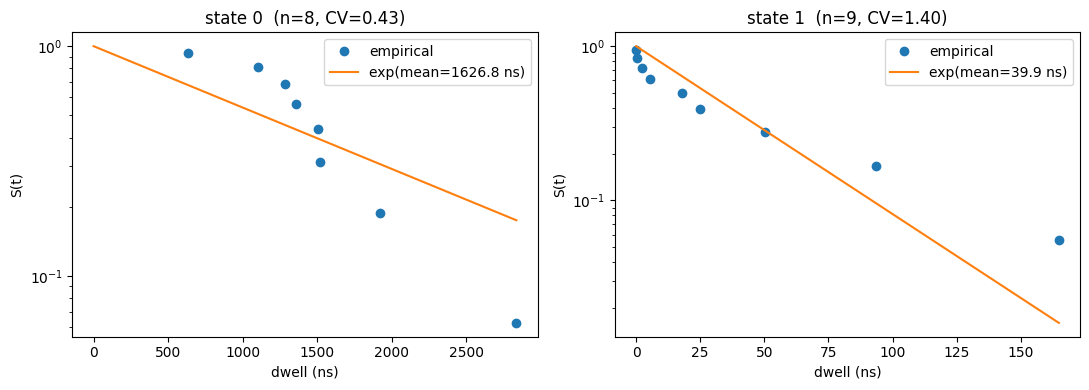

In [10]:
from src.twostate import two_state_model

frametime = 1e-3  # ns per frame (1 ps/frame)
cv = sd.cvs[:, 0]
core0 = lambda x: x < 0
core1 = lambda x: x > 6

m = two_state_model(cv, core0=core0, core1=core1, frametime=frametime)
k01, k10 = m["rates"]
p0, p1 = m["pi"]
mfpt01, mfpt10 = m["mfpt"]  # == mean dwells for a 2-state system
dwells0, dwells1 = m["dwells"]
tau_rel, t2 = m["tau_relax"], m["t2"]
T_tot = cv.size * frametime

print(f"frames         {cv.size:,}   ({T_tot/1e3:.2f} us total)")
print(f"transitions    n01={m['n01']}   n10={m['n10']}\n")
print(f"populations    p0 = {p0:.4f}     p1 = {p1:.4f}")
print(f"rates          k01 = {k01:.3e}/ns   k10 = {k10:.3e}/ns")
print(f"mean dwell     <t0> = {mfpt01/1e3:.3f} us    <t1> = {mfpt10:.2f} ns")
print(f"MFPT           0->1 = {mfpt01/1e3:.3f} us    1->0 = {mfpt10:.2f} ns\n")
print(f"tau_relax      {tau_rel:.2f} ns")
print(f"t2 (eigval)    {t2:.2f} ns      <- should match tau_relax")
print(f"~tau_int       {2*tau_rel:.2f} ns    (2x, two-sided ACF convention)\n")
print("T (lag 1 frame):")
print(np.array2string(m["T"], precision=6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, d, name, mean in [
    (axes[0], dwells0, "state 0", mfpt01),
    (axes[1], dwells1, "state 1", mfpt10),
]:
    d = np.sort(np.asarray(d))
    n = d.size
    S = 1.0 - (np.arange(1, n + 1) - 0.5) / n  # empirical survival
    cvar = d.std(ddof=1) / d.mean()
    tt = np.linspace(0, d.max(), 200)
    ax.semilogy(d, S, "o", label="empirical")
    ax.semilogy(tt, np.exp(-tt / mean), "-", label=f"exp(mean={mean:.1f} ns)")
    ax.set_title(f"{name}  (n={n}, CV={cvar:.2f})")
    ax.set_xlabel("dwell (ns)")
    ax.set_ylabel("S(t)")
    ax.legend()
plt.tight_layout()
plt.show()

# Parrinello's dataset
*

# Main plot for all ACFs (FUTURE)

In [ ]:
# def compute_acfs(wd, signals, lagtime, num_frames_acf, calculate=True):
#     file = wd / "acfs.pickle"
#     if calculate:
#         acfs = {
#             label: compute_acf_dataclass(u, lagtime, num_frames_acf)
#             for label, u in signals.items()
#         }
#         save_pickle(file, acfs)
#     else:
#         acfs = load_pickle(file)
#     return acfs


# signals = {
#     r"$\psi_1(x)$": sd.cvs[:, 0],
#     r"$\psi_2(x)$": sd.cvs[:, 1],
#     r"$\phi$": sd.dihedrals[:, 0],
#     r"$\psi$": sd.dihedrals[:, 1],
# }
# acfs = compute_acfs(sd.working_dir, signals, lagtime, num_frames_acf, calculate=True)

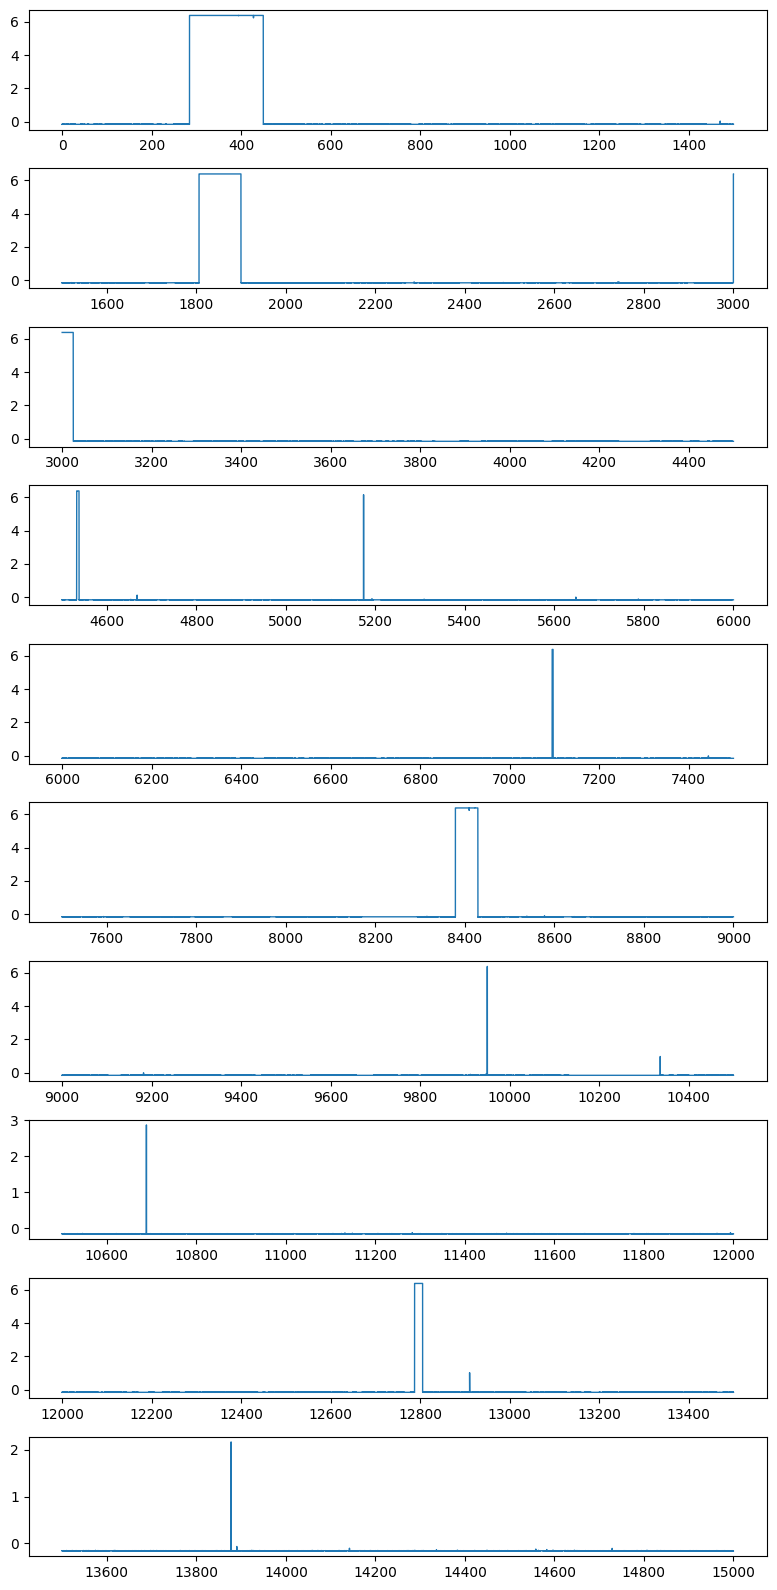

In [3]:
import importlib
import openmm.unit as unit
import src.util

importlib.reload(src.util)

from src.util import chunk_iter

ns = np.arange(len(sd.cvs)) * p.lagtime / unit.nanosecond
lagtime = p.lagtime / unit.picosecond

num_chunks = 10
titer = chunk_iter(ns, num_chunks)
uiter = chunk_iter(sd.cvs[:, 0], num_chunks)

fig, axs = plt.subplots(num_chunks, 1, figsize=(8, 16))
for t, u, ax in zip(titer, uiter, axs):
    ax.plot(t, u, lw=1)
fig.tight_layout()